In [ ]:
# Time Series Forecasting on Hourly Energy Consumption

# Objective
#The objective of this notebook is to compare different forecasting models on hourly energy consumption data.

#The workflow includes:

#Data preprocessing
# Data visualization
# Train-test split
# Baseline forecasting models
# SARIMA forecasting
# Performance evaluation using MAE and MAPE
# ACF/PACF analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')       # The dataset is stored in Google Drive, so mount the drive to access it

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['education loan.pdf',
 'DSC_0097.JPG',
 'vanshika_certificates.pdf',
 'vanshika_agrawal_23scse1180119.docx',
 'Colab Notebooks',
 'vanshika_agrawal_23scse1180119_compressed.pdf',
 'Vanshika_Resume.pdf',
 'IMG20250714221913.jpg',
 'IMG_20250714_223311.jpg',
 'certificate.pdf',
 'Vanshika Resume.pdf',
 '144552104.zip',
 'pan card vanshika.pdf',
 'Vanshika Agrawal passbook.pdf',
 'archive.zip',
 'PlantDoc.zip',
 'Interview Rubrics (Job Fair).xlsx',
 'AI-Powered Plant Disease Detection & Recommendation System_compressed.pdf',
 'feedback vanshika .pdf',
 'Image-20251129T060925Z-1-001.zip',
 'Image',
 'resume (4).pdf',
 'rain_model.joblib',
 'Medical Image Classification (Brain Tumor Classification)report.pdf',
 'Medical_Image_Class.ipynb',
 'ImageBasedClassification.ipynb',
 'feedback form.pdf',
 'Mall_Customers.csv',
 'resume (1) (2).pdf',
 'vanshika resume (3).pdf',
 'vanshika resume (2).pdf',
 'vanshika resume (1).pdf',
 'vanshika resume.pdf',
 'vanshi resume.pdf',
 'nptel result (1).pd

In [ ]:
import zipfile
#extract the zip file
zip_path = "/content/drive/MyDrive/forcastin dataset.zip"
extract_path = "/content/hourly_energy"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
import os
os.listdir(extract_path)

['AEP_hourly.csv',
 'PJMW_hourly.csv',
 'PJM_Load_hourly.csv',
 'NI_hourly.csv',
 'COMED_hourly.csv',
 'PJME_hourly.csv',
 'DAYTON_hourly.csv',
 'DUQ_hourly.csv',
 'est_hourly.paruqet',
 'DOM_hourly.csv',
 'pjm_hourly_est.csv',
 'FE_hourly.csv',
 'EKPC_hourly.csv',
 'DEOK_hourly.csv']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
df = pd.read_csv("/content/hourly_energy/AEP_hourly.csv")

In [ ]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.set_index("Datetime", inplace=True)
df.sort_index(inplace=True)
display(df.head())

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


In [ ]:
df.info()
print("Shape :", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

display(df.describe())
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121273 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121273 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB
Shape : (121273, 1)

Missing Values
AEP_MW    0
dtype: int64


,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


,0
AEP_MW,0


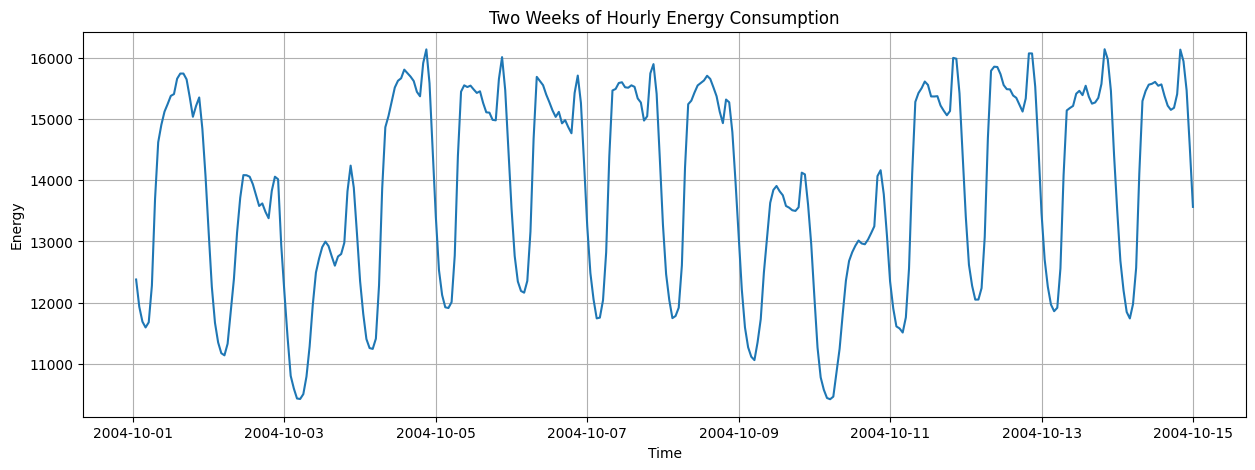

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df.iloc[:24*14])
plt.title("Two Weeks of Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.grid(True)
plt.show()

In [ ]:
energy_data = df.tail(24 * 90)                       # Use the most recent 90 days to reduce computation time
target = energy_data.columns[0]

train_data = energy_data.iloc[:-24*7][target]           # Reserve the last 7 days for testing
test_data = energy_data.iloc[-24*7:][target]

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_data,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

sarima_pred = sarima_result.predict(
    start=test_data.index[0],
    end=test_data.index[-1]
)      #SARIMA captures both trend and seasonal patterns in the data, making it suitable for hourly energy consumption forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error
)
# Naive Forecast
naive_pred = test_data.shift(1)
naive_pred.iloc[0] = train_data.iloc[-1]

# Combine train and test data for seasonal forecasts
combined_data = pd.concat([train_data, test_data])

# Seasonal Naive (24)
season24_pred = combined_data.shift(24).loc[test_data.index]

# Seasonal Naive (168)
season168_pred = combined_data.shift(168).loc[test_data.index]

mae_naive = mean_absolute_error(test_data, naive_pred)
mae_24 = mean_absolute_error(test_data, season24_pred)
mae_168 = mean_absolute_error(test_data, season168_pred)
mae_sarima = mean_absolute_error(test_data, sarima_pred)

mape_naive = mean_absolute_percentage_error(test_data, naive_pred)
mape_24 = mean_absolute_percentage_error(test_data, season24_pred)
mape_168 = mean_absolute_percentage_error(test_data, season168_pred)
mape_sarima = mean_absolute_percentage_error(test_data, sarima_pred)

In [ ]:
leaderboard = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive (24)",
        "Seasonal Naive (168)",
        "SARIMA"
    ],
    "MAE": [
        mae_naive,
        mae_24,
        mae_168,
        mae_sarima
    ],
    "MAPE": [
        mape_naive,
        mape_24,
        mape_168,
        mape_sarima
    ]
})

leaderboard["MAE"] = leaderboard["MAE"].round(2)
leaderboard["MAPE"] = (leaderboard["MAPE"] * 100).round(2)

leaderboard = leaderboard.sort_values("MAE").reset_index(drop=True)

display(leaderboard)

leaderboard

,Model,MAE,MAPE
0,Naive,484.44,3.34
1,Seasonal Naive (168),642.60,4.04
2,Seasonal Naive (24),887.07,5.91
3,SARIMA,1012.91,6.89


,Model,MAE,MAPE
0,Naive,484.44,3.34
1,Seasonal Naive (168),642.60,4.04
2,Seasonal Naive (24),887.07,5.91
3,SARIMA,1012.91,6.89


In [ ]:
## Model Performance

#The table below compares the forecasting models using MAE and MAPE.

#Seasonal Naive (168) achieved the lowest error, indicating that weekly seasonality is the strongest pattern in the dataset.

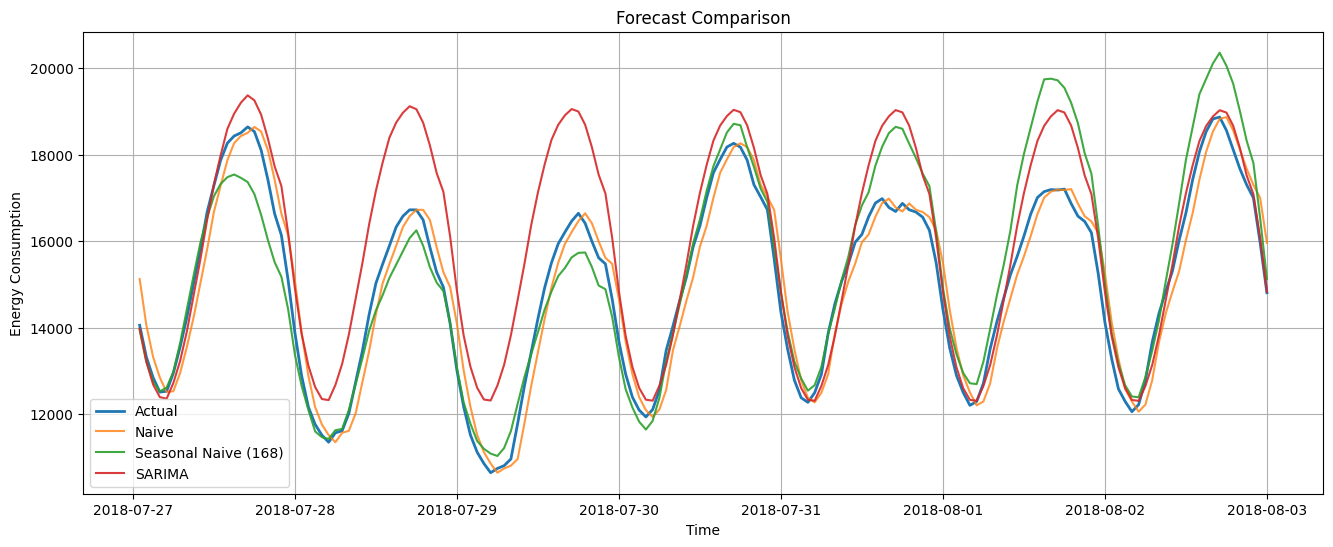

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(test_data,
         label="Actual",
         linewidth=2)

plt.plot(naive_pred,
         label="Naive",
         alpha=0.8)

plt.plot(season168_pred,
         label="Seasonal Naive (168)",
         alpha=0.9)

plt.plot(sarima_pred,
         label="SARIMA",
         alpha=0.9)

plt.title("Forecast Comparison")

plt.xlabel("Time")

plt.ylabel("Energy Consumption")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_data)

print("ADF Statistic:", result[0])

print("p-value:", result[1])

if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

ADF Statistic: -4.074225122961986
p-value: 0.0010680232086711795
The time series is stationary.


In [ ]:
# Interpretation -The ADF test returned a p-value below 0.05, indicating that the time series is stationary.
#Therefore, the null hypothesis of non-stationarity is rejected.

<Figure size 1200x400 with 0 Axes>

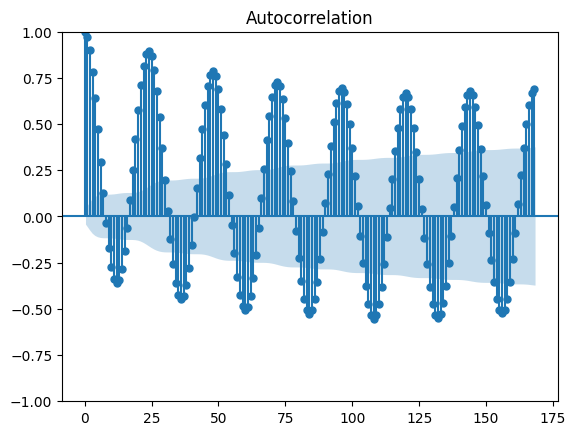

In [ ]:
plt.figure(figsize=(12,4))

plot_acf(train_data, lags=168)
plt.show()

In [ ]:
#The PACF plot is limited to 48 lags for readability. Weekly seasonality (lag 168) is more clearly observed in the ACF plot.

<Figure size 1200x400 with 0 Axes>

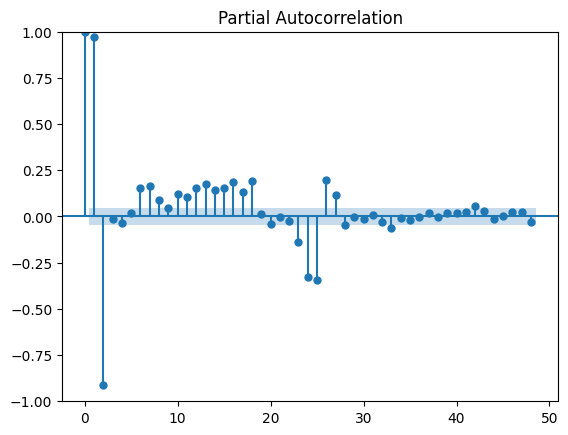

In [ ]:
plt.figure(figsize=(12,4))

plot_pacf(train_data, lags=48)
plt.show()

In [ ]:
# Observations:
# Lag 24:Strong spike indicates daily seasonality.
# Lag 168:Strong spike indicates weekly seasonality.

In [ ]:
# Conclusion

# Among the baseline forecasting models, the Naive model achieved the lowest MAE (484.44),
# outperforming Seasonal Naive (168) and SARIMA on this 90-day subset.
# This suggests that the most recent observation was a stronger predictor than the same hour
# from the previous week. One possible reason is that this subset showed stronger short-term
# continuity than week-to-week regularity, making the Naive model a better baseline for this experiment.

In [ ]:
#Lightgbm part
# Install and Import Required Libraries

!pip install lightgbm

import lightgbm as lgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [ ]:
# Feature Engineering

# Create a copy of the existing dataset
feature_data = energy_data.copy()

# Lag Features
feature_data["lag_1"] = feature_data[target].shift(1)
feature_data["lag_24"] = feature_data[target].shift(24)
feature_data["lag_168"] = feature_data[target].shift(168)

# Rolling Mean (24 Hours)
feature_data["rolling_mean_24"] = (
    feature_data[target]
    .shift(1)
    .rolling(window=24)
    .mean()
)

# Rolling Std (24 Hours)
feature_data["rolling_std_24"] = (
    feature_data[target]
    .shift(1)
    .rolling(window=24)
    .std()
)

# Rolling Mean (168 Hours)
feature_data["rolling_mean_168"] = (
    feature_data[target]
    .shift(1)
    .rolling(window=168)
    .mean()
)

# Rolling Std (168 Hours)
feature_data["rolling_std_168"] = (
    feature_data[target]
    .shift(1)
    .rolling(window=168)
    .std()
)

# Time Features
feature_data["hour"] = feature_data.index.hour
feature_data["day_of_week"] = feature_data.index.dayofweek
feature_data["is_weekend"] = (
    feature_data["day_of_week"] >= 5
).astype(int)

# Remove rows with missing values
feature_data.dropna(inplace=True)

feature_data.head()

,AEP_MW,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,hour,day_of_week,is_weekend
Datetime,,,,,,,,,,,
2018-05-12 01:00:00,11617.0,12327.0,11813.0,11352.0,13512.166667,1636.687314,13008.238095,1670.762031,1,5,1
2018-05-12 02:00:00,10913.0,11617.0,11345.0,10967.0,13504.000000,1645.996883,13009.815476,1669.313465,2,5,1
2018-05-12 03:00:00,10702.0,10913.0,11006.0,10566.0,13486.000000,1672.777643,13009.494048,1669.714318,3,5,1
2018-05-12 04:00:00,10366.0,10702.0,10869.0,10317.0,13473.333333,1693.397169,13010.303571,1668.555116,4,5,1
2018-05-12 05:00:00,10455.0,10366.0,10892.0,10358.0,13452.375000,1729.753534,13010.595238,1668.085719,5,5,1


In [ ]:
# Train-Test Split for LightGBM

train_ml = feature_data.iloc[:-24*7]
test_ml = feature_data.iloc[-24*7:]

feature_columns = [

    "lag_1",
    "lag_24",
    "lag_168",

    "rolling_mean_24",
    "rolling_std_24",

    "rolling_mean_168",
    "rolling_std_168",

    "hour",
    "day_of_week",
    "is_weekend"

]

X_train = train_ml[feature_columns]
X_test = test_ml[feature_columns]

y_train = train_ml[target]
y_test = test_ml[target]

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (1824, 10)
Testing Shape : (168, 10)


In [ ]:
# LightGBM Model

lightgbm_model = lgb.LGBMRegressor(

    n_estimators=300,

    learning_rate=0.05,

    random_state=42

)

lightgbm_model.fit(

    X_train,

    y_train

)

lightgbm_pred = lightgbm_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000349 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1818
[LightGBM] [Info] Number of data points in the train set: 1824, number of used features: 10
[LightGBM] [Info] Start training from score 15402.600329


In [ ]:
# LightGBM Evaluation

mae_lightgbm = mean_absolute_error(

    y_test,

    lightgbm_pred

)

mape_lightgbm = mean_absolute_percentage_error(

    y_test,

    lightgbm_pred

)

print("LightGBM MAE :", round(mae_lightgbm,2))

print("LightGBM MAPE :", round(mape_lightgbm*100,2),"%")

LightGBM MAE : 121.92
LightGBM MAPE : 0.82 %


In [ ]:
# Updated Model Comparison

leaderboard = pd.DataFrame({

    "Model":[

        "Naive",

        "Seasonal Naive (24)",

        "Seasonal Naive (168)",

        "SARIMA",

        "LightGBM"

    ],

    "MAE":[

        mae_naive,

        mae_24,

        mae_168,

        mae_sarima,

        mae_lightgbm

    ],

    "MAPE":[

        mape_naive,

        mape_24,

        mape_168,

        mape_sarima,

        mape_lightgbm

    ]

})

leaderboard["MAE"] = leaderboard["MAE"].round(2)

leaderboard["MAPE"] = (

    leaderboard["MAPE"]*100

).round(2)

leaderboard = leaderboard.sort_values(

    by="MAE"

).reset_index(drop=True)

display(leaderboard)

,Model,MAE,MAPE
0,LightGBM,121.92,0.82
1,Naive,484.44,3.34
2,Seasonal Naive (168),642.60,4.04
3,Seasonal Naive (24),887.07,5.91
4,SARIMA,1012.91,6.89


In [ ]:
# Observation

# LightGBM was compared with the four statistical forecasting models.

 # The comparison was performed using both MAE and MAPE.

 # The leaderboard shows whether feature-engineered machine learning can outperform statistical forecasting methods.

In [ ]:
# Feature Importance

importance = pd.DataFrame({

    "Feature":feature_columns,

    "Importance":lightgbm_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

display(importance)

,Feature,Importance
0,lag_1,1626
7,hour,1464
3,rolling_mean_24,1249
4,rolling_std_24,1105
6,rolling_std_168,821
5,rolling_mean_168,821
1,lag_24,802
2,lag_168,708
8,day_of_week,404
9,is_weekend,0


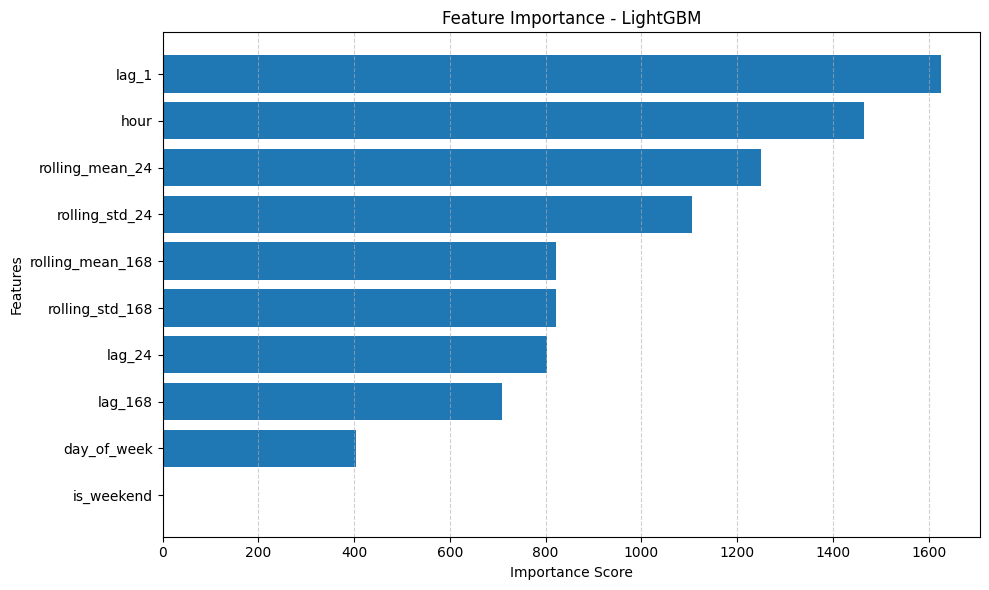

In [ ]:
# Feature Importance Plot

import matplotlib.pyplot as plt

# Sort features by importance
importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance - LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

In [ ]:
# Feature Importance Interpretation

# The feature importance plot shows that lag_1 and hour were the most influential
# features for the LightGBM model. This indicates that the model relied mainly on
# the most recent observation and the time of day while making predictions.
# Features such as lag_168 contributed much less in this experiment, suggesting
# that recent historical values were more informative than weekly historical values
# for this 90-day subset.

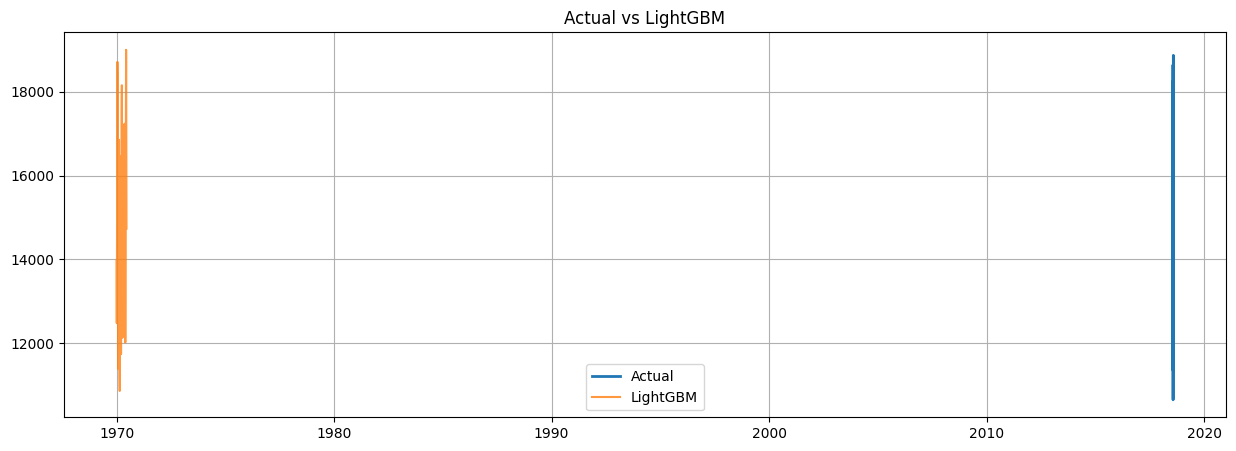

In [ ]:
# Actual vs LightGBM Prediction

plt.figure(figsize=(15,5))

plt.plot(

    y_test,

    label="Actual",

    linewidth=2

)

plt.plot(

    lightgbm_pred,

    label="LightGBM",

    alpha=0.8

)

plt.legend()

plt.title("Actual vs LightGBM")

plt.grid(True)

plt.show()

In [ ]:
# LightGBM Analysis

# LightGBM achieved the lowest MAE and MAPE among all the models evaluated.
# The model benefited from the engineered lag, rolling, and calendar features,
# allowing it to capture short-term temporal patterns effectively.
# The feature importance plot showed that lag_1 and hour had the highest influence
# on the predictions, indicating that recent observations and the time of day were
# the most useful features for this dataset.